# 第 02 期：Logistic 回归与滑坡易发性

本期用滑坡易发性评价作为案例，讲解 Logistic 回归的基本原理、实现方法和地学解释。

## 1. 导入必要的库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    roc_curve, 
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. Sigmoid 函数可视化

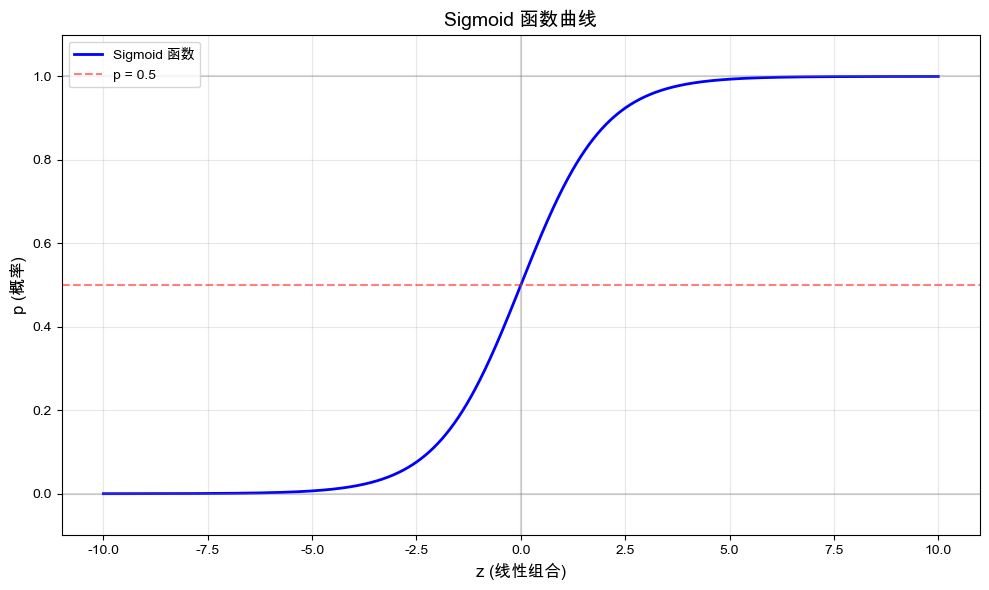

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 1000)
p = sigmoid(z)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(z, p, 'b-', linewidth=2, label='Sigmoid 函数')
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='p = 0.5')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('z (线性组合)', fontsize=12)
ax.set_ylabel('p (概率)', fontsize=12)
ax.set_title('Sigmoid 函数曲线', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('figures/sigmoid_function.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 构造教学数据

In [3]:
np.random.seed(42)
n_samples = 500

slope = np.random.uniform(5, 45, n_samples)
elevation = np.random.uniform(500, 2500, n_samples)
fault_dist = np.random.uniform(50, 3000, n_samples)
road_dist = np.random.uniform(20, 1500, n_samples)
ndvi = np.random.uniform(0.1, 0.9, n_samples)

log_odds = (
    -5 + 
    0.12 * slope + 
    0.001 * elevation + 
    -0.002 * fault_dist + 
    -0.003 * road_dist + 
    -3 * ndvi
)

prob = sigmoid(log_odds)
landslide = (np.random.random(n_samples) < prob).astype(int)

data = pd.DataFrame({
    'slope': slope,
    'elevation': elevation,
    'fault_dist': fault_dist,
    'road_dist': road_dist,
    'ndvi': ndvi,
    'landslide': landslide
})

print("数据概览：")
print(data.head(10))
print(f"\n数据形状: {data.shape}")
print(f"\n滑坡点数量: {landslide.sum()} ({landslide.mean()*100:.1f}%)")
print(f"非滑坡点数量: {n_samples - landslide.sum()} ({(1-landslide.mean())*100:.1f}%)")

数据概览：
       slope    elevation   fault_dist    road_dist      ndvi  landslide
0  19.981605  1896.323428   596.142140   788.241042  0.309365          0
1  43.028572  1572.192733  1648.607795   729.189179  0.297583          0
2  34.279758  1119.055233  2625.190216    57.950257  0.825004          0
3  28.946339  2127.590039  2210.063415   525.046785  0.299637          0
4  11.240746  1869.462345  2429.355386   582.689516  0.317560          0
5  11.239781   825.233879  1993.410932   610.257716  0.707519          0
6   7.323344  2321.854369  2092.215865   878.655106  0.459792          0
7  39.647046  2145.074486  2555.127172   809.731769  0.721368          0
8  29.044600  2399.599827   786.520626   919.699537  0.152293          0
9  33.322903  1951.439017  1493.803643  1152.027227  0.490057          0

数据形状: (500, 6)

滑坡点数量: 8 (1.6%)
非滑坡点数量: 492 (98.4%)


## 4. 数据探索与可视化

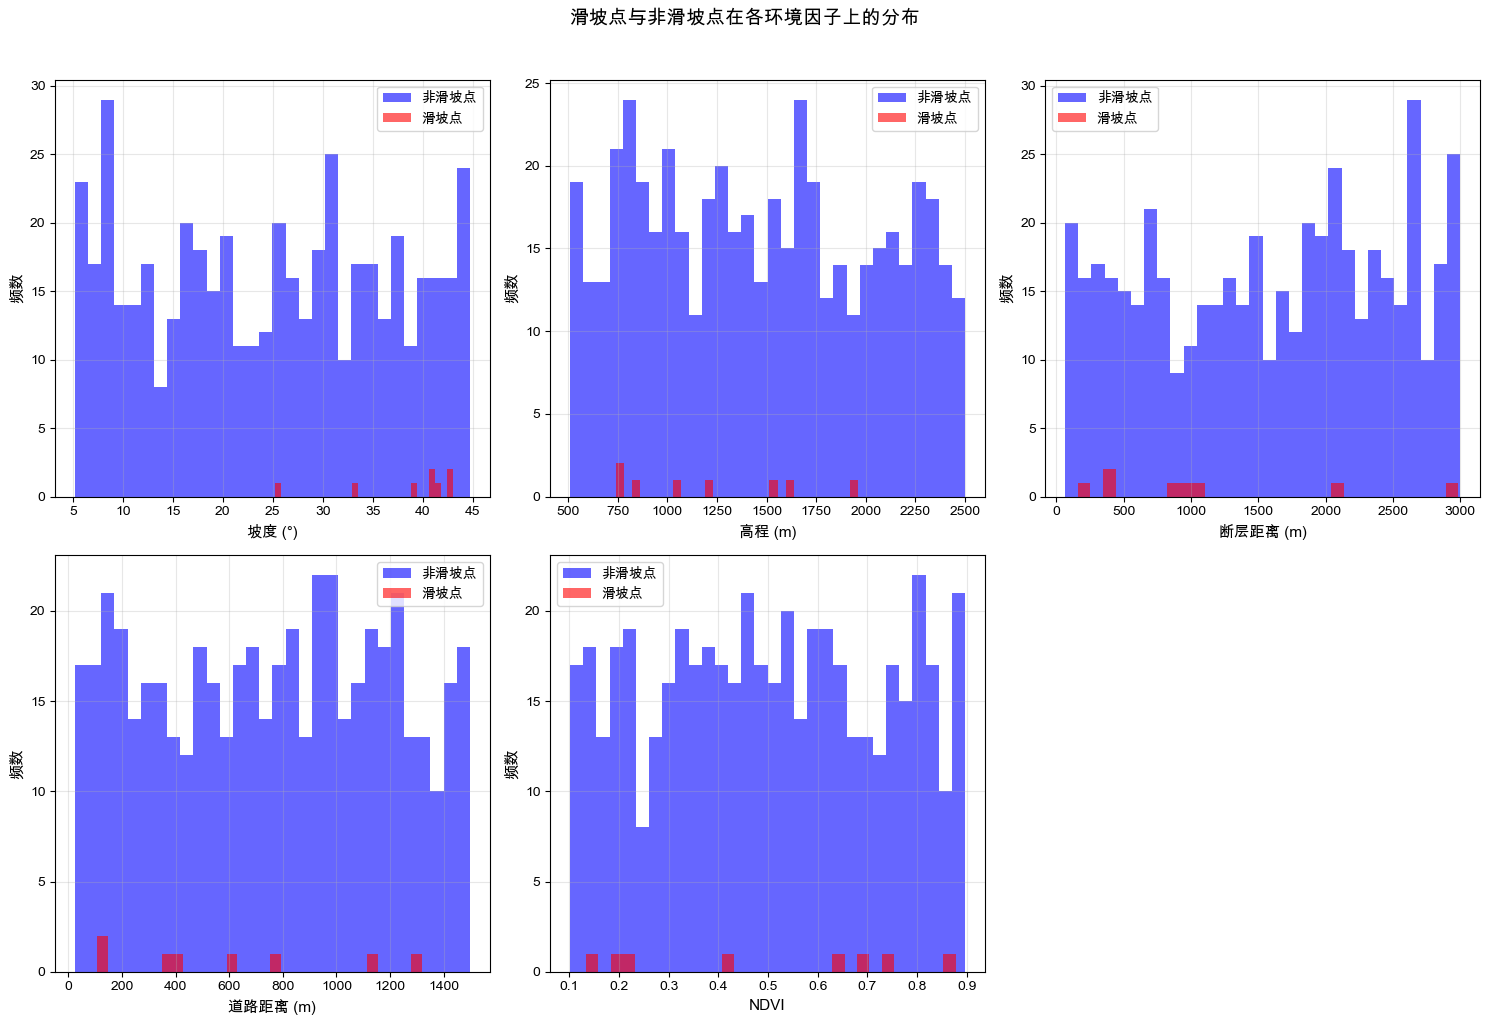

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['slope', 'elevation', 'fault_dist', 'road_dist', 'ndvi']
feature_names = ['坡度 (°)', '高程 (m)', '断层距离 (m)', '道路距离 (m)', 'NDVI']

for idx, (feat, name) in enumerate(zip(features, feature_names)):
    ax = axes[idx // 3, idx % 3]
    ax.hist(data[data['landslide']==0][feat], bins=30, alpha=0.6, label='非滑坡点', color='blue')
    ax.hist(data[data['landslide']==1][feat], bins=30, alpha=0.6, label='滑坡点', color='red')
    ax.set_xlabel(name, fontsize=11)
    ax.set_ylabel('频数', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')
fig.suptitle('滑坡点与非滑坡点在各环境因子上的分布', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/landslide_factors_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 数据预处理与训练集划分

In [5]:
X = data[features]
y = data['landslide']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")
print(f"\n训练集滑坡比例: {y_train.mean()*100:.1f}%")
print(f"测试集滑坡比例: {y_test.mean()*100:.1f}%")

训练集大小: 350
测试集大小: 150

训练集滑坡比例: 1.7%
测试集滑坡比例: 1.3%


## 6. 训练 Logistic 回归模型

In [6]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("="*50)
print("模型参数")
print("="*50)
print(f"截距 (Intercept): {model.intercept_[0]:.4f}")
print("\n各特征系数：")
for feat, coef in zip(features, model.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

print("\n" + "="*50)
print("几率比 (Odds Ratio)")
print("="*50)
for feat, coef in zip(features, model.coef_[0]):
    or_value = np.exp(coef)
    print(f"  {feat}: {or_value:.4f}")

模型参数
截距 (Intercept): -5.1833

各特征系数：
  slope: 1.3969
  elevation: -0.6969
  fault_dist: -0.7186
  road_dist: -0.0702
  ndvi: 0.2033

几率比 (Odds Ratio)
  slope: 4.0427
  elevation: 0.4981
  fault_dist: 0.4874
  road_dist: 0.9322
  ndvi: 1.2254


## 7. 模型性能评估

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("分类性能指标")
print("="*50)
print(f"准确率 (Accuracy): {accuracy:.4f}")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall): {recall:.4f}")
print(f"F1 分数: {f1:.4f}")
print(f"AUC: {auc:.4f}")

print("\n" + "="*50)
print("分类报告")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['非滑坡', '滑坡']))

分类性能指标
准确率 (Accuracy): 0.9867
精确率 (Precision): 0.0000
召回率 (Recall): 0.0000
F1 分数: 0.0000
AUC: 0.7601

分类报告
              precision    recall  f1-score   support

         非滑坡       0.99      1.00      0.99       148
          滑坡       0.00      0.00      0.00         2

    accuracy                           0.99       150
   macro avg       0.49      0.50      0.50       150
weighted avg       0.97      0.99      0.98       150



## 8. 混淆矩阵

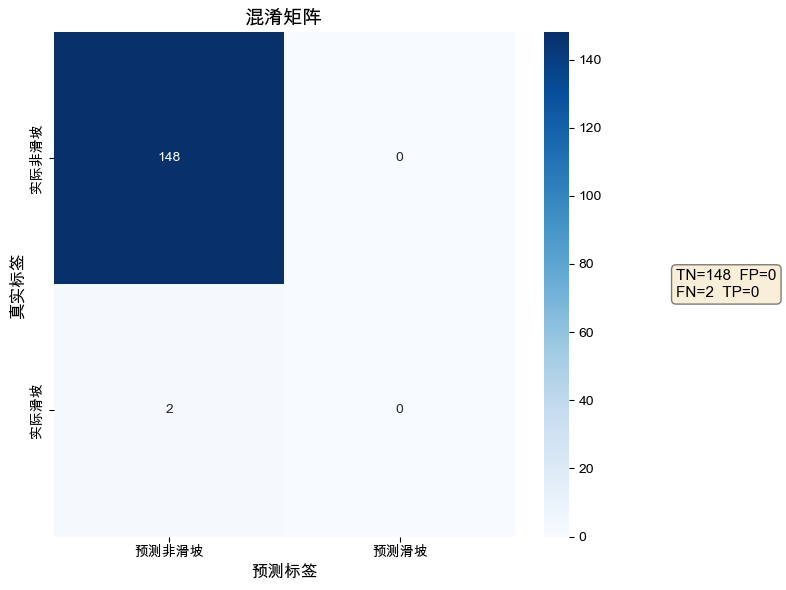

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['预测非滑坡', '预测滑坡'],
            yticklabels=['实际非滑坡', '实际滑坡'])
ax.set_xlabel('预测标签', fontsize=12)
ax.set_ylabel('真实标签', fontsize=12)
ax.set_title('混淆矩阵', fontsize=14)

tn, fp, fn, tp = cm.ravel()
textstr = f'TN={tn}  FP={fp}\nFN={fn}  TP={tp}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(1.35, 0.5, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', bbox=props)

plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC 曲线

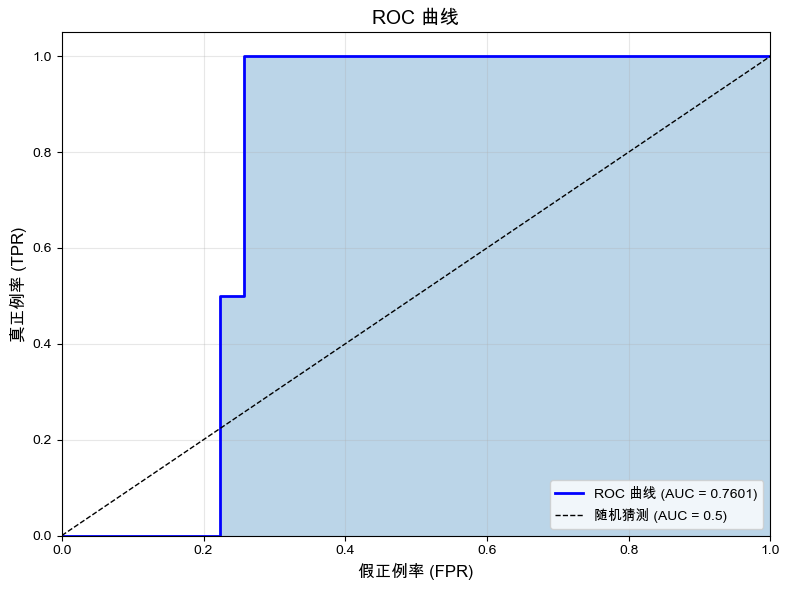

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC 曲线 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测 (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.3)
ax.set_xlabel('假正例率 (FPR)', fontsize=12)
ax.set_ylabel('真正例率 (TPR)', fontsize=12)
ax.set_title('ROC 曲线', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 模拟滑坡易发性图

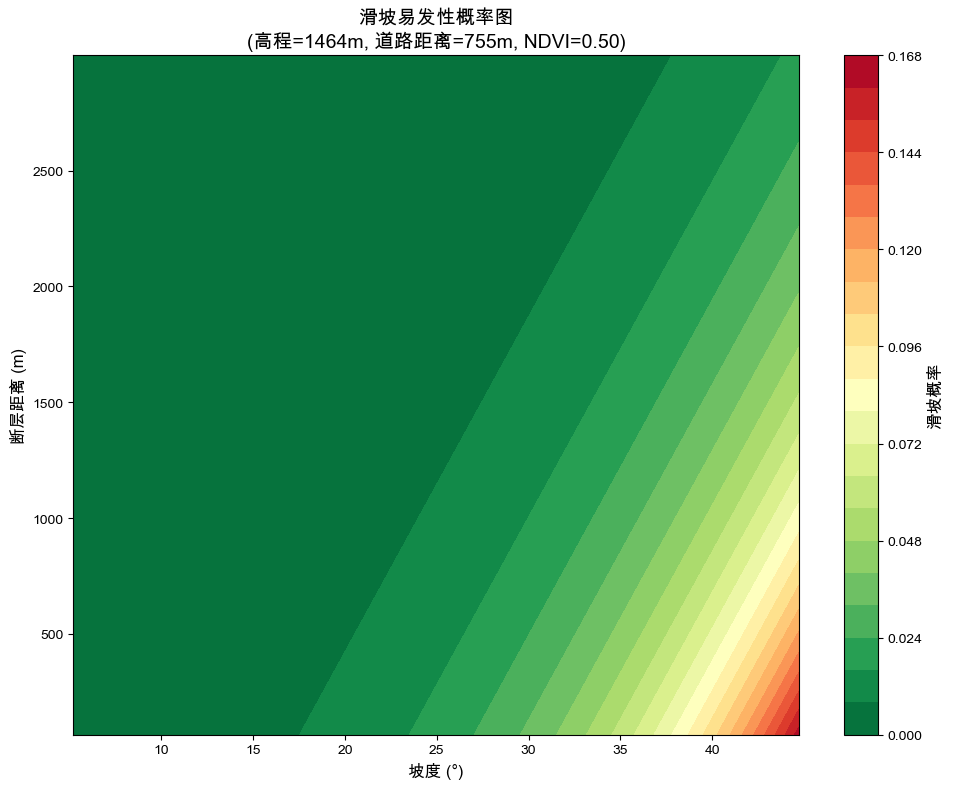

In [10]:
n_grid = 100
slope_grid = np.linspace(data['slope'].min(), data['slope'].max(), n_grid)
fault_dist_grid = np.linspace(data['fault_dist'].min(), data['fault_dist'].max(), n_grid)

SLOPE, FAULT_DIST = np.meshgrid(slope_grid, fault_dist_grid)

mean_elevation = data['elevation'].mean()
mean_road_dist = data['road_dist'].mean()
mean_ndvi = data['ndvi'].mean()

grid_data = pd.DataFrame({
    'slope': SLOPE.flatten(),
    'elevation': mean_elevation,
    'fault_dist': FAULT_DIST.flatten(),
    'road_dist': mean_road_dist,
    'ndvi': mean_ndvi
})

grid_scaled = scaler.transform(grid_data)
grid_prob = model.predict_proba(grid_scaled)[:, 1]
PROB = grid_prob.reshape(SLOPE.shape)

fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(SLOPE, FAULT_DIST, PROB, levels=20, cmap='RdYlGn_r')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('滑坡概率', fontsize=12)
ax.set_xlabel('坡度 (°)', fontsize=12)
ax.set_ylabel('断层距离 (m)', fontsize=12)
ax.set_title(f'滑坡易发性概率图\n(高程={mean_elevation:.0f}m, 道路距离={mean_road_dist:.0f}m, NDVI={mean_ndvi:.2f})', fontsize=14)
plt.tight_layout()
plt.savefig('figures/susceptibility_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 系数解释与总结

In [11]:
print("="*60)
print("模型系数解释")
print("="*60)

coef_df = pd.DataFrame({
    '特征': features,
    '系数': model.coef_[0],
    '几率比': np.exp(model.coef_[0]),
    '影响方向': ['增加风险' if c > 0 else '降低风险' for c in model.coef_[0]]
})

print(coef_df.to_string(index=False))

print("\n" + "="*60)
print("地学解释")
print("="*60)
print("""
1. 坡度 (slope): 系数为正，坡度越大滑坡风险越高
   - 符合物理直觉：陡坡更容易发生滑坡

2. 高程 (elevation): 系数取决于区域特征
   - 不同区域可能有不同表现

3. 断层距离 (fault_dist): 系数为负，距断层越近风险越高
   - 断层附近岩体破碎，稳定性差

4. 道路距离 (road_dist): 系数为负，距道路越近风险越高
   - 道路开挖改变坡体应力状态

5. NDVI: 系数为负，植被覆盖越高风险越低
   - 植被根系固土，减少侵蚀
""")

print("\n" + "="*60)
print("本期要点总结")
print("="*60)
print("""
1. Logistic 回归适合二分类问题，输出概率估计
2. Sigmoid 函数将线性组合映射到 [0, 1] 区间
3. 系数可解释为因子对事件发生的影响方向和强度
4. 评估分类模型需关注混淆矩阵、ROC 曲线和 AUC
5. 阈值选择需要权衡漏报和误报的代价
""")

模型系数解释
        特征        系数      几率比 影响方向
     slope  1.396924 4.042745 增加风险
 elevation -0.696895 0.498130 降低风险
fault_dist -0.718587 0.487441 降低风险
 road_dist -0.070245 0.932166 降低风险
      ndvi  0.203290 1.225428 增加风险

地学解释

1. 坡度 (slope): 系数为正，坡度越大滑坡风险越高
   - 符合物理直觉：陡坡更容易发生滑坡

2. 高程 (elevation): 系数取决于区域特征
   - 不同区域可能有不同表现

3. 断层距离 (fault_dist): 系数为负，距断层越近风险越高
   - 断层附近岩体破碎，稳定性差

4. 道路距离 (road_dist): 系数为负，距道路越近风险越高
   - 道路开挖改变坡体应力状态

5. NDVI: 系数为负，植被覆盖越高风险越低
   - 植被根系固土，减少侵蚀


本期要点总结

1. Logistic 回归适合二分类问题，输出概率估计
2. Sigmoid 函数将线性组合映射到 [0, 1] 区间
3. 系数可解释为因子对事件发生的影响方向和强度
4. 评估分类模型需关注混淆矩阵、ROC 曲线和 AUC
5. 阈值选择需要权衡漏报和误报的代价

